# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green? 

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'munsell-array-fixed-choice.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

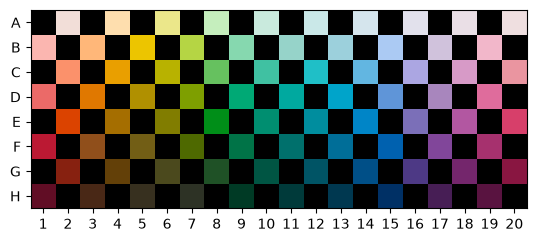

In [3]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

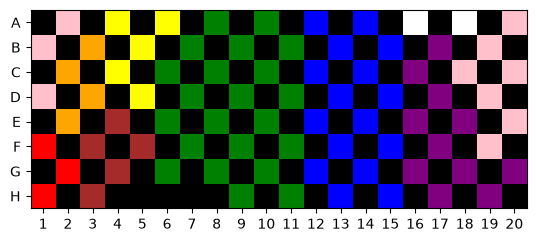

In [4]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

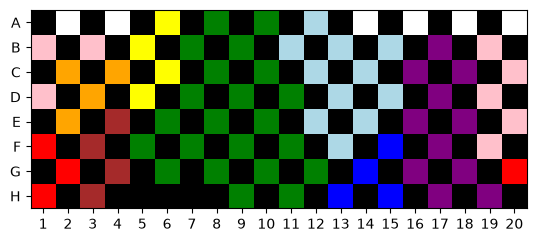

In [6]:
plot_colors('spanish_color')

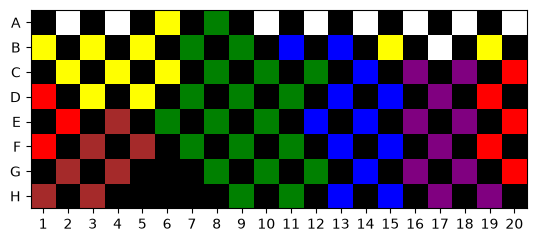

In [7]:
plot_colors('tsimane_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots. 
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.
	
	- You might need to `merge` dataframes.


Question 1: 
For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

In [17]:
#For English:
eng = (
    df.groupby('english_color')
    .size()
    .reset_index(name ='count')
)
eng = eng.eval('eng_percent = (count / count.sum()) * 100 ')
eng

,english_color,count,eng_percent
0,black,2,2.50
1,blue,16,20.00
2,brown,5,6.25
3,green,22,27.50
4,orange,4,5.00
5,pink,10,12.50
6,purple,11,13.75
7,red,3,3.75
8,white,2,2.50
9,yellow,5,6.25


In [18]:
#For Spanish:
spa = (
    df.groupby('spanish_color')
    .size()
    .reset_index(name ='count')
)
spa = spa.eval('spa_percent = (count / count.sum()) * 100 ')
spa

,spanish_color,count,spa_percent
0,black,2,2.50
1,blue,4,5.00
2,brown,4,5.00
3,green,22,27.50
4,lightblue,11,13.75
5,orange,4,5.00
6,pink,8,10.00
7,purple,11,13.75
8,red,4,5.00
9,white,6,7.50


In [19]:
#For Tsimane`:
tsi = (
    df.groupby('tsimane_color')
    .size()
    .reset_index(name ='count')
)
tsi = tsi.eval('tsi_percent = (count / count.sum()) * 100 ')
tsi

,tsimane_color,count,tsi_percent
0,black,3,3.75
1,blue,12,15.00
2,brown,7,8.75
3,green,20,25.00
4,purple,10,12.50
5,red,8,10.00
6,white,9,11.25
7,yellow,11,13.75


Question 2:
Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

Text(0, 0.5, 'Color')

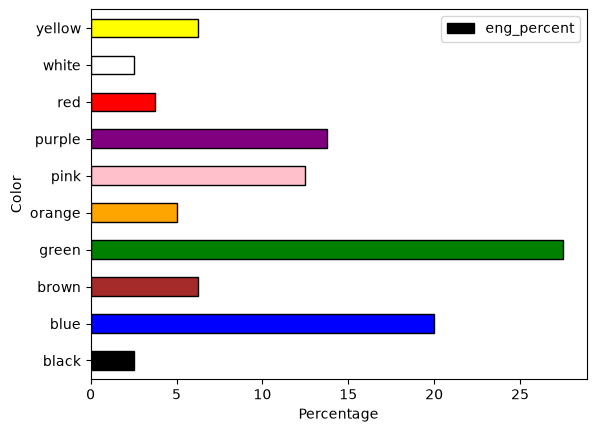

In [37]:
#For English:

eng.plot.barh(
    x = 'english_color', 
    y = 'eng_percent', 
    color = eng['english_color'],
    edgecolor = 'black'
)

plt.xlabel('Percentage')
plt.ylabel('Color')

Text(0, 0.5, 'Color')

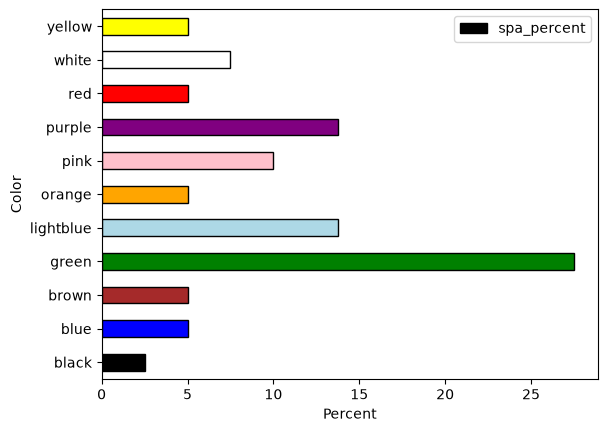

In [43]:
#For Spanish

spa.plot.barh(
    x = 'spanish_color',
    y = 'spa_percent',
    color = spa['spanish_color'],
    edgecolor = 'black'
)

plt.xlabel('Percent')
plt.ylabel('Color')

Text(0, 0.5, 'Color')

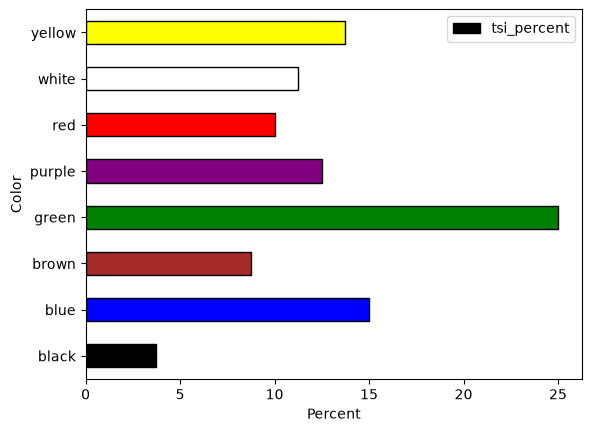

In [47]:
#For Tsimane

tsi.plot.barh(
    x = 'tsimane_color',
    y = 'tsi_percent',
    color = tsi['tsimane_color'],
    edgecolor = 'black'
)

plt.xlabel('Percent')
plt.ylabel('Color')

Quesiton 3: Is there a correlation between languages? Create scatter plots. 
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.
	
	- You might need to `merge` dataframes.

In [74]:
eng['Color'] = eng['english_color']
tsi['Color'] = tsi['tsimane_color']

#merging
merged = eng.merge(tsi, on = 'Color', how = 'left').fillna(0)
merged = merged.drop(['english_color', 'tsimane_color'], axis =1) #cleaning the table by removing redundant columns
merged

,count_x,eng_percent,Color,count_y,tsi_percent
0,2,2.50,black,3.0,3.75
1,16,20.00,blue,12.0,15.00
2,5,6.25,brown,7.0,8.75
3,22,27.50,green,20.0,25.00
4,4,5.00,orange,0.0,0.00
5,10,12.50,pink,0.0,0.00
6,11,13.75,purple,10.0,12.50
7,3,3.75,red,8.0,10.00
8,2,2.50,white,9.0,11.25
9,5,6.25,yellow,11.0,13.75


Text(0.5, 1.0, 'Comparison of Percentage of Color Chips for English and Tsiname Speakers')

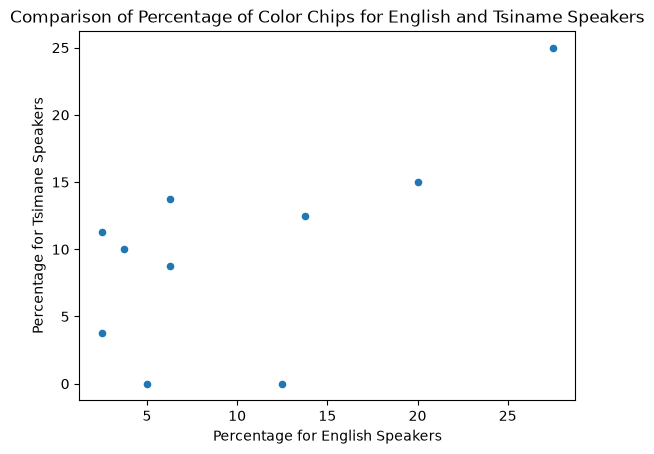

In [84]:
#creating a scatter
merged.plot.scatter(
    x = 'eng_percent',
    y = 'tsi_percent'
)

plt.xlabel('Percentage for English Speakers')
plt.ylabel('Percentage for Tsimane Speakers')
plt.title('Comparison of Percentage of Color Chips for English and Tsiname Speakers')

In [85]:
#Correlation
merged['eng_percent'].corr(merged['tsi_percent'])

np.float64(0.6593008524966988)

A correlation coefficient (r) value of ~0.65930 indicates a **moderately strong positive linear correlation** between the variables english percent and tsiname percent.